# Example 9: Ephemeris and Almanac Fitting

This tutorial shows how LuPNT compresses a numerically propagated lunar trajectory into broadcast-friendly navigation models. A receiver cannot practically receive a dense trajectory table, so a navigation service broadcasts compact parameters instead.

We compare two representations:

- `pnt.CartesianEphemeris`: a short-validity, high-accuracy model consisting of an osculating two-body baseline plus Chebyshev Cartesian residual corrections;
- `pnt.Almanac`: a long-validity, lower-accuracy model that fits slowly varying orbital-element histories with low-order polynomials and Fourier terms.

Both models solve the same tutorial problem: trade broadcast data size against fit error. LuPNT's `EphemerisSimulation` automates this by sweeping fit-window length, fitting several windows, and estimating how many bits are needed per parameter to keep the worst-case position error below a target.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import os, sys
from pathlib import Path

# Use THIS repo's pylupnt/data, not a stale copy on a global PYTHONPATH (~/.zshrc) or kernelspec.
for _b in [Path.cwd(), *Path.cwd().parents]:
    if (_b / "python/pylupnt/__init__.py").exists():
        sys.path.insert(0, str((_b / "python").resolve()))
        if (_b / "data/LuPNT_data/ephemeris").is_dir():
            os.environ["LUPNT_DATA_PATH"] = str((_b / "data/LuPNT_data").resolve())
        break
import pylupnt as pnt

[00.01][PyLuPNT] Initializing


## Truth trajectory

We reuse the Elliptical Lunar Frozen Orbit (ELFO) from Example 1: classical
orbital elements defined in the Moon-centered **Orbital Plane (OP)** frame,
converted to the **Moon-Centered Inertial (MCI)** frame and propagated with
N-body dynamics (Moon gravity + Earth/Sun third-body).

In [2]:
t0 = pnt.gregorian_to_time(2027, 1, 1, 0, 0, 0)  # [s] TDB

a = 6541.4e3  # [m]   semi-major axis
e = 0.6  # [-]   eccentricity
i = 56.2 * pnt.RAD  # [rad] inclination
raan = 0.0 * pnt.RAD  # [rad] right ascension of the ascending node
w = 90.0 * pnt.RAD  # [rad] argument of perigee
M0 = 0.0 * pnt.RAD  # [rad] mean anomaly
coe0_op = np.array([a, e, i, raan, w, M0])

period = pnt.get_orbital_period(a, pnt.GM_MOON)  # [s]
print(f"Orbital period: {period / pnt.SECS_HOUR:.2f} hours")

rv0_op = pnt.classical_to_cart(coe0_op, pnt.GM_MOON)
rv0_mci = pnt.convert_frame(t0, rv0_op, pnt.MOON_OP, pnt.MOON_CI)

dyn = pnt.NBodyDynamics()
dyn.set_frame(pnt.MOON_CI)
dyn.set_units(pnt.SI_UNITS)
dyn.add_body(pnt.create_body(pnt.MOON, 8, 8))
dyn.add_body(pnt.create_body(pnt.EARTH))
dyn.add_body(pnt.create_body(pnt.SUN))
dyn.set_integrator(pnt.IntegratorType.RKF45)
params = pnt.IntegratorParams()
params.reltol = 1e-10
params.abstol = 1e-6
dyn.set_integrator_params(params)
dyn.set_time_step(30.0)  # propagation timestep [s]; see Example 1

# The ephemeris is a *short-validity* model, so we fit/evaluate it over windows of
# up to ~2 hours: propagate a short, densely sampled truth trajectory for it.
eph_dt_s = 60.0
eph_days = 1.0
t_eph_s = np.arange(0, eph_days * pnt.SECS_DAY + eph_dt_s, eph_dt_s)  # elapsed [s]
rv_truth_eph = dyn.propagate(rv0_mci, t0 + t_eph_s)  # [N x 6], MCI frame
print(
    f"Ephemeris truth: {eph_days:.0f} day  -- {len(t_eph_s)} samples at {eph_dt_s:.0f} s spacing"
)

# The almanac is a *long-validity* model, so we fit/evaluate it over windows of up
# to ~15 days: propagate a long, coarsely sampled truth trajectory for it.
alm_dt_s = 600.0
alm_days = 16.0
t_alm_s = np.arange(0, alm_days * pnt.SECS_DAY + alm_dt_s, alm_dt_s)  # elapsed [s]
rv_truth_alm = dyn.propagate(rv0_mci, t0 + t_alm_s)  # [N x 6], MCI frame
print(
    f"Almanac truth:   {alm_days:.0f} days -- {len(t_alm_s)} samples at {alm_dt_s:.0f} s spacing"
)

Orbital period: 13.19 hours
Ephemeris truth: 1 day  -- 1441 samples at 60 s spacing
Almanac truth:   16 days -- 2305 samples at 600 s spacing


## How the models are represented

Both models are fit and evaluated in the Moon-fixed **principal-axis (PA)** frame.
The osculating two-body elements are formed in the quasi-inertial **PAI** frame
(the PA axes frozen at a reference epoch); PA and PAI share the same position, and
their velocities differ by the Moon's rotation $\boldsymbol\omega = \omega_M\,\hat{\mathbf z}$
($\omega_M = 2.6617\times10^{-6}\,$rad/s) about the pole:

$$
\mathbf r_{\mathrm{PA}} = \mathbf r_{\mathrm{PAI}}, \qquad
\mathbf v_{\mathrm{PA}} = \mathbf v_{\mathrm{PAI}} - \boldsymbol\omega\times\mathbf r .
$$

Let $t_k = t-t_0$ with $t_0$ the reference epoch (the window **midpoint** for the
ephemeris, the window **start** for the almanac), and $T_{\mathrm{fit}}$ the window
length.

### Ephemeris (`CartesianEphemeris`)

At $t_0$ the osculating elements $(a,e,i,\Omega,\omega,M_0)$ are read off the PA
state (adding $\boldsymbol\omega\times\mathbf r$ to recover the inertial velocity).
The two-body **baseline** is propagated in PAI,

$$
M(t)=M_0+n\,t_k,\qquad n=\sqrt{\mu/a^{3}},
$$

solved for the eccentric/true anomaly and mapped to Cartesian
$\mathbf r_{\mathrm{PAI}}(t)$, then rotated into the rotating PA frame,

$$
\mathbf r^{\mathrm{OE}}_{\mathrm{PA}}(t)=R_z(-\omega_M t_k)\,\mathbf r_{\mathrm{PAI}}(t)
\;\;\Longleftrightarrow\;\; \Omega(t)=\Omega-\omega_M t_k ,
$$

with the velocity given by the exact time derivative (carrying the
$-\boldsymbol\omega\times\mathbf r$ term). A **Chebyshev** correction (basis
$T_0=1,\,T_1=\tau,\,T_{j+1}=2\tau T_j-T_{j-1}$ on $\tau=2t_k/T_{\mathrm{fit}}\in[-1,1]$)
is added to each PA position component $d\in\{x,y,z\}$, and optionally $M$ Fourier
harmonics of the argument of latitude $u=\omega+\nu$:

$$
\Delta r_d(t)=\sum_{j=0}^{N} c_{d,j}\,T_j(\tau)
\;+\;\sum_{h=1}^{M}\big[a_{d,h}\cos(hu)+b_{d,h}\sin(hu)\big].
$$

The broadcast state is baseline + correction (velocity from the analytic
derivatives $\dot T_j$, $\tfrac{d}{dt}\cos hu$, ...):

$$
\mathbf r(t)=\mathbf r^{\mathrm{OE}}_{\mathrm{PA}}(t)+\Delta\mathbf r(t),\qquad
\mathbf v(t)=\mathbf v^{\mathrm{OE}}_{\mathrm{PA}}(t)+\Delta\dot{\mathbf r}(t).
$$

The parameters $\{a,e,i,\Omega,\omega,M_0\}\cup\{c_{d,j}\}\cup\{a_{d,h},b_{d,h}\}$
are found by linear least squares on the position residual ($M=0$ gives the pure
Chebyshev model used below).

### Almanac (`Almanac`, Algorithm 2 of Iiyama & Gao)

Over a long window the almanac fits each osculating **element's time history** as a
low-order polynomial ($s=t_k/T_{\mathrm{fit}}$, order $P$; **linear**, $P=1$, by
default) plus a single element-specific Fourier term:

$$
\xi(t)=\sum_{p=0}^{P}\beta^{\xi}_p\,s^{p}
      +C^{\xi}_c\cos(\omega_\xi t_k)+C^{\xi}_s\sin(\omega_\xi t_k),
\qquad \xi\in\{a,\,e,\,i,\,\Omega\},
$$

with base frequency $\omega_a=\sqrt{\mu/a_{\mathrm{ref}}^{3}}$ (orbital mean motion)
for the semi-major axis and $\omega_\xi=4\pi/T_{\mathrm{sid}}$
($T_{\mathrm{sid}}=27.32\,$d) for the rest. The mean anomaly removes the nominal
two-body drift and fits only the residual with the same basis,

$$
M(t)=\int_{0}^{t_k}\! n\big(a(t')\big)\,dt' \;+\;\big[\text{poly}+\text{Fourier}\big]^{M}(t).
$$

Crucially, instead of correcting the argument of periapsis directly, the
**argument of latitude** is corrected,

$$
u(t)=\nu(t)+\big[\text{poly}+\text{Fourier}\big]^{u}(t),
$$

where $\nu$ is the true anomaly from the fitted $M$. Building the position directly
from $(a,e,i,\Omega,u)$ keeps the reconstruction well-conditioned near periapsis
(the position error scales like $r\,\delta u$, and $r$ is *smallest* at periapsis),
so a linear fit does not blow up on eccentric orbits. Evaluation returns the PA
state (velocity via the analytic two-body rate, minus $\boldsymbol\omega\times\mathbf r$).

### Fit-error evaluation

Fitted states are differenced against the (denser) truth and rotated into the
local **radial/transverse/normal (RTN)** frame at each truth state, with rows
$\hat{\mathbf R}=\mathbf r/\lVert\mathbf r\rVert$,
$\hat{\mathbf N}=(\mathbf r\times\mathbf v)/\lVert\mathbf r\times\mathbf v\rVert$,
$\hat{\mathbf T}=\hat{\mathbf N}\times\hat{\mathbf R}$. For the position error
$\delta\mathbf r_k=\mathbf r^{\mathrm{fit}}_k-\mathbf r^{\mathrm{ref}}_k$ (and
likewise velocity) over $N$ samples, we report the RMS and 95th percentile of the
3-D magnitude (per-axis versions use the RTN components):

$$
\mathrm{RMS}=\sqrt{\tfrac1N\sum_{k=1}^{N}\lVert\delta\mathbf r_k\rVert^{2}},\qquad
P_{95}=\mathrm{percentile}_{95}\big(\{\lVert\delta\mathbf r_k\rVert\}\big).
$$

## Fitting a single window

Fit each model over a window matched to its intended validity: a **2-hour**
window for the short-validity `CartesianEphemeris`, and a **15-day** window for
the long-validity `Almanac`. Each is then evaluated against the (denser) truth
samples inside its own window.

Both models are fit and evaluated in the **Moon-fixed principal-axis (`MOON_PA`)**
frame -- the rotating body-fixed frame a lunar navigation broadcast uses so that a
surface user can compute topocentric geometry directly. Internally the osculating
elements are fit in the quasi-inertial Principal-Axis Inertial (PAI) frame and the
two-body baseline's node drifts at the Moon's rotation rate, placing it in the
rotating output frame (`EphemerisFitOptions.frame` / `AlmanacFitOptions.frame`).

In [3]:
# Ephemeris: short (2-hour) window from the densely sampled truth trajectory.
eph_window_hr = 2.0
n_eph = int(round(eph_window_hr * pnt.SECS_HOUR / eph_dt_s)) + 1
t_eph_win = t_eph_s[:n_eph]
rv_eph_win = rv_truth_eph[:n_eph]

# Almanac: long (15-day) window from the coarsely sampled truth trajectory.
alm_window_days = 15.0
n_alm = int(round(alm_window_days * pnt.SECS_DAY / alm_dt_s)) + 1
t_alm_win = t_alm_s[:n_alm]
rv_alm_win = rv_truth_alm[:n_alm]

# Broadcast in the Moon-fixed principal-axis (PA) frame: convert each truth arc
# from MCI to MOON_PA and fit in that frame, so the fitted output is PA -- the
# frame a surface user works in (per Iiyama & Gao, "Ephemeris and Almanac Design
# for Lunar Navigation Satellites"). Internally the osculating elements are fit in
# the Principal-Axis Inertial (PAI) frame and the node drifts at the Moon's
# rotation rate to place the two-body baseline in the rotating PA frame.
rv_eph_win_pa = pnt.convert_frame(t0 + t_eph_win, rv_eph_win, pnt.MOON_CI, pnt.MOON_PA)
rv_alm_win_pa = pnt.convert_frame(t0 + t_alm_win, rv_alm_win, pnt.MOON_CI, pnt.MOON_PA)

cart_opts = pnt.EphemerisFitOptions()
cart_opts.poly_order = 8
cart_opts.use_keplerian_baseline = True
cart_opts.frame = pnt.MOON_PA
cart_eph = pnt.CartesianEphemeris(cart_opts)

# Almanac (Algorithm 2 of Iiyama & Gao): each element is a *linear* polynomial
# plus one element-specific Fourier term, and the argument of periapsis is
# replaced by an argument-of-latitude correction u = nu + (linear + Fourier). The
# u-parameterization stays well-conditioned near periapsis, so a linear fit is
# enough -- keeping the message small.
alm_opts = pnt.AlmanacFitOptions()
alm_opts.poly_order = 1
alm_opts.num_fourier_terms = 1
alm_opts.frame = pnt.MOON_PA
almanac = pnt.Almanac(alm_opts)

params_cart = cart_eph.fit(t_eph_win, rv_eph_win_pa)
params_alm = almanac.fit(t_alm_win, rv_alm_win_pa)

print(
    f"CartesianEphemeris ({eph_window_hr:.0f}-hour window, MOON_PA): "
    f"{cart_eph.num_params()} params -> {cart_eph.param_names()}"
)
print(
    f"Almanac ({alm_window_days:.0f}-day window, MOON_PA): "
    f"{almanac.num_params()} params -> {almanac.param_names()}"
)

err_cart = cart_eph.eval_error(t_eph_win, rv_eph_win_pa, params_cart)
err_alm = almanac.eval_error(t_alm_win, rv_alm_win_pa, params_alm)

summary = pd.DataFrame(
    {
        "CartesianEphemeris (2 hr)": [
            err_cart.rms_pos_m[3],
            err_cart.p95_pos_m[3],
            err_cart.rms_vel_mps[3],
            err_cart.p95_vel_mps[3],
        ],
        "Almanac (15 day)": [
            err_alm.rms_pos_m[3],
            err_alm.p95_pos_m[3],
            err_alm.rms_vel_mps[3],
            err_alm.p95_vel_mps[3],
        ],
    },
    index=["RMS pos [m]", "95% pos [m]", "RMS vel [m/s]", "95% vel [m/s]"],
)
summary

CartesianEphemeris (2-hour window, MOON_PA): 35 params -> ['t_ref', 't_fit', 'a', 'e', 'i', 'raan', 'argp', 'M_ref', 'x_0', 'x_1', 'x_2', 'x_3', 'x_4', 'x_5', 'x_6', 'x_7', 'x_8', 'y_0', 'y_1', 'y_2', 'y_3', 'y_4', 'y_5', 'y_6', 'y_7', 'y_8', 'z_0', 'z_1', 'z_2', 'z_3', 'z_4', 'z_5', 'z_6', 'z_7', 'z_8']
Almanac (15-day window, MOON_PA): 27 params -> ['t_ref', 't_fit', 'a_ref', 'a_p0', 'a_p1', 'a_fc1', 'a_fs1', 'e_p0', 'e_p1', 'e_fc1', 'e_fs1', 'i_p0', 'i_p1', 'i_fc1', 'i_fs1', 'raan_p0', 'raan_p1', 'raan_fc1', 'raan_fs1', 'M_p0', 'M_p1', 'M_fc1', 'M_fs1', 'u_p0', 'u_p1', 'u_fc1', 'u_fs1']


,CartesianEphemeris (2 hr),Almanac (15 day)
RMS pos [m],0.183543,11155.323621
95% pos [m],0.318240,19557.026335
RMS vel [m/s],0.001540,1.870680
95% vel [m/s],0.002027,3.911634


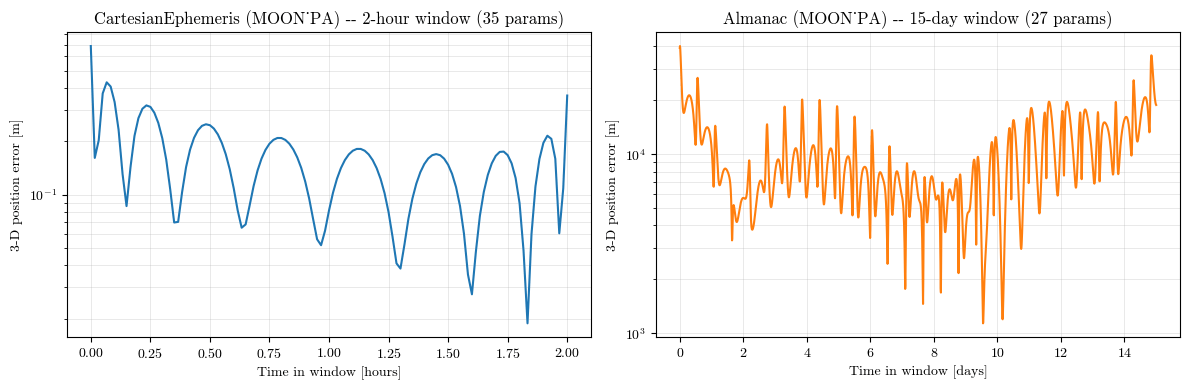

In [4]:
fit_cart = cart_eph.eval(t_eph_win, params_cart)
fit_alm = almanac.eval(t_alm_win, params_alm)

t_eph_hr = (t_eph_win - t_eph_win[0]) / pnt.SECS_HOUR
t_alm_day = (t_alm_win - t_alm_win[0]) / pnt.SECS_DAY
# Both fit and truth are in MOON_PA here.
pos_err_cart = np.linalg.norm(fit_cart[:, :3] - rv_eph_win_pa[:, :3], axis=1)
pos_err_alm = np.linalg.norm(fit_alm[:, :3] - rv_alm_win_pa[:, :3], axis=1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(t_eph_hr, pos_err_cart, color="C0")
axes[0].set_xlabel("Time in window [hours]")
axes[0].set_ylabel("3-D position error [m]")
axes[0].set_yscale("log")
axes[0].set_title(
    f"CartesianEphemeris (MOON_PA) -- {eph_window_hr:.0f}-hour window "
    f"({cart_eph.num_params()} params)"
)
axes[0].grid(True, which="both", lw=0.4, alpha=0.5)

axes[1].plot(t_alm_day, pos_err_alm, color="C1")
axes[1].set_xlabel("Time in window [days]")
axes[1].set_ylabel("3-D position error [m]")
axes[1].set_yscale("log")
axes[1].set_title(
    f"Almanac (MOON_PA) -- {alm_window_days:.0f}-day window "
    f"({almanac.num_params()} params)"
)
axes[1].grid(True, which="both", lw=0.4, alpha=0.5)

plt.tight_layout()
plt.show()

## Almanac prediction error for a South-Pole user

A surface user uses the almanac to assist satellite tracking: the parameters 
they would need are where to point it (azimuth/elevation), how far away it is (range),
 and how fast that range changes (the Doppler shift). 
 
Here we push both the **truth** trajectory and the **almanac** fit (the 15-day fit from above)
through those observables for a user at the lunar **South Pole**, and look at the almanac's prediction error in each.

Because the almanac already broadcasts in the Moon-fixed `MOON_PA` frame, its
prediction is *directly* in the user's frame -- only the truth trajectory
(propagated in MCI) still needs rotating into `MOON_PA`. Both are then converted to
azimuth/elevation/range relative to the user; range-rate is the line-of-sight
relative velocity, converted to a Doppler shift at a nominal S-band carrier. We
report the error statistics over the **entire** window and, separately, only where
the satellite is actually **visible** (truth elevation above 5°).

In [5]:
# User at the lunar South Pole, in the Moon-fixed (MOON_PA) frame.
user_lla = np.array([-90.0, 0.0, 0.0])  # [lat deg, lon deg, alt m]
user_pa = pnt.lat_lon_alt_to_cart(user_lla, pnt.R_MOON)

tfs_alm = t0 + t_alm_win  # absolute epochs [s, TDB]
f_carrier_hz = 2.4e9  # nominal S-band carrier

# The almanac now broadcasts directly in MOON_PA, so its evaluation is already in
# the user's frame -- no MCI->PA conversion of the prediction is needed. Only the
# raw truth trajectory (propagated in MCI) still has to be rotated into MOON_PA.
pred_pa = almanac.eval(t_alm_win, params_alm)
truth_pa = pnt.convert_frame(tfs_alm, rv_alm_win, pnt.MOON_CI, pnt.MOON_PA)


def observables(rv_pa):
    """(az[deg], el[deg], range[m], range-rate[m/s], Doppler[Hz]) at the user."""
    aer = np.asarray(pnt.cart_to_az_el_range(rv_pa[:, :3], user_pa))
    az_deg = np.rad2deg(aer[:, 0])
    el_deg = np.rad2deg(aer[:, 1])
    rng_m = aer[:, 2]
    rel = rv_pa[:, :3] - user_pa
    range_rate = np.sum(rel * rv_pa[:, 3:], axis=1) / np.linalg.norm(rel, axis=1)
    doppler_hz = -range_rate * f_carrier_hz / pnt.C
    return az_deg, el_deg, rng_m, range_rate, doppler_hz


az_t, el_t, rng_t, rr_t, dop_t = observables(truth_pa)
az_p, el_p, rng_p, rr_p, dop_p = observables(pred_pa)


def wrap_deg(d):  # wrap an angular error into [-180, 180) deg
    return (d + 180.0) % 360.0 - 180.0


az_err = wrap_deg(az_p - az_t)  # [deg]
el_err = el_p - el_t  # [deg]
rng_err = rng_p - rng_t  # [m]
dop_err = dop_p - dop_t  # [Hz]

visible = el_t > 5.0  # truth elevation above the 5 deg mask
t_alm_day = (t_alm_win - t_alm_win[0]) / pnt.SECS_DAY

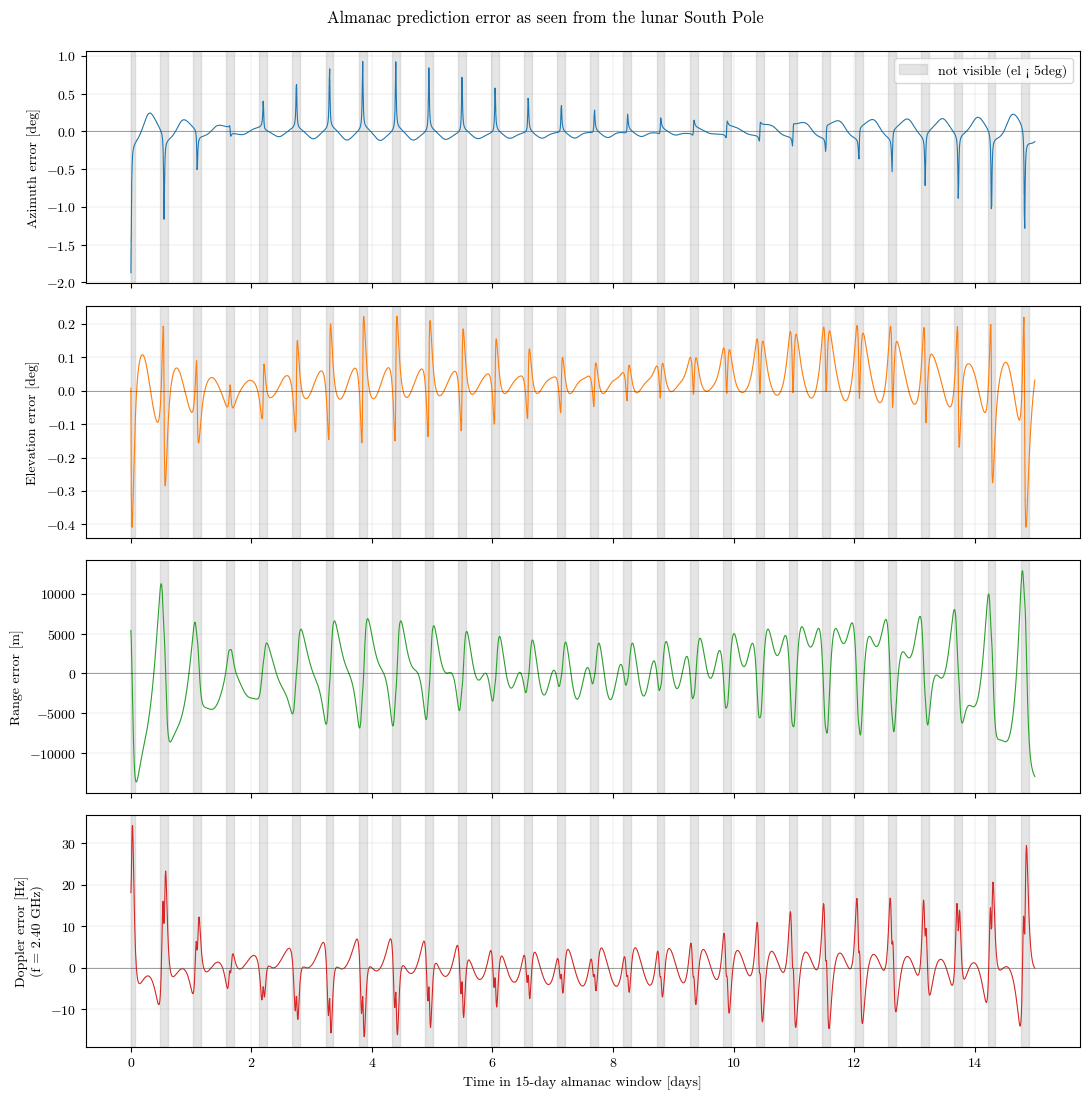

In [6]:
panels = [
    (az_err, "Azimuth error [deg]", "C0"),
    (el_err, "Elevation error [deg]", "C1"),
    (rng_err, "Range error [m]", "C2"),
    (dop_err, f"Doppler error [Hz]\n(f = {f_carrier_hz / 1e9:.2f} GHz)", "C3"),
]

fig, axes = plt.subplots(4, 1, figsize=(11, 11), sharex=True)
for ax, (y, ylabel, color) in zip(axes, panels):
    ax.plot(t_alm_day, y, lw=0.8, color=color)
    ax.axhline(0.0, color="k", lw=0.5, alpha=0.5)
    lo, hi = ax.get_ylim()
    ax.fill_between(
        t_alm_day,
        lo,
        hi,
        where=~visible,
        color="0.6",
        alpha=0.25,
        label="not visible (el < 5deg)",
    )
    ax.set_ylim(lo, hi)
    ax.set_ylabel(ylabel)
    ax.grid(True, lw=0.3, alpha=0.5)

axes[0].legend(loc="upper right")
axes[-1].set_xlabel("Time in 15-day almanac window [days]")
fig.suptitle("Almanac prediction error as seen from the lunar South Pole", y=0.995)
plt.tight_layout()
plt.show()

In [7]:
# Statistics over the entire window vs. only where the satellite is visible.
def err_stats(err, mask):
    x = err[mask]
    ax = np.abs(x)
    return np.sqrt(np.mean(x**2)), np.mean(x), np.percentile(ax, 95), ax.max()


all_mask = np.ones_like(visible, dtype=bool)
metrics = {
    "Azimuth [deg]": az_err,
    "Elevation [deg]": el_err,
    "Range [m]": rng_err,
    "Doppler [Hz]": dop_err,
}

records = []
for name, err in metrics.items():
    for scope, mask in [
        ("entire trajectory", all_mask),
        ("visible (el>5deg)", visible),
    ]:
        rms, bias, p95, mx = err_stats(err, mask)
        records.append((name, scope, rms, bias, p95, mx))

stats_tbl = pd.DataFrame.from_records(
    records, columns=["error", "scope", "RMS", "bias", "P95|err|", "max|err|"]
).set_index(["error", "scope"])

print(
    f"Samples: {len(el_t)} total, {int(visible.sum())} visible "
    f"({100 * visible.mean():.1f}% of the 15-day window); "
    f"truth elevation in [{el_t.min():.1f}, {el_t.max():.1f}] deg"
)
stats_tbl

Samples: 2161 total, 1625 visible (75.2% of the 15-day window); truth elevation in [-73.7, 58.3] deg


RMS        bias     P95|err|  \
error           scope                                                     
Azimuth [deg]   entire trajectory     0.142409   -0.000310     0.215602   
                visible (el>5deg)     0.081997    0.001793     0.159638   
Elevation [deg] entire trajectory     0.075161    0.023250     0.160610   
                visible (el>5deg)     0.048553    0.021228     0.100052   
Range [m]       entire trajectory  4152.495094   40.503434  8148.573014   
                visible (el>5deg)  4035.466760  184.178682  8096.365485   
Doppler [Hz]    entire trajectory     5.377799    0.117951    12.289185   
                visible (el>5deg)     3.123072    0.037270     6.248297   

                                       max|err|  
error           scope                            
Azimuth [deg]   entire trajectory      1.870645  
                visible (el>5deg)      0.242256  
Elevation [deg] entire trajectory      0.409135  
                visible (el>5deg)      0.217960  
Range [m]       entire trajectory  13640.427015  
                visible (el>5deg)  13640.427015  
Doppler [Hz]    entire trajectory     34.305053  
                visible (el>5deg)     14.143630

## Accuracy vs. datasize trade-off

`pnt.EphemerisSimulation` automates the study above across a sweep of fitting-
window lengths: for each window length it samples several windows across the
truth trajectory, fits/evaluates both models on each, and searches (by
bisection) the minimum per-parameter broadcast resolution that keeps the
worst-case position error (over the window) under `datasize_precision_m` --
giving a total bit count per window length.

The reported accuracy is the **realized** broadcast error. For each parameter
$\theta_j$ a bisection finds the fewest fractional bits $k_j$ such that perturbing
$\theta_j$ by $2^{-k_j}$ moves the position -- anywhere in the window -- by less
than the target $\varepsilon$; the broadcast value is quantized to that
resolution,

$$
\hat\theta_j = 2^{-k_j}\,\operatorname{round}\!\big(\theta_j\,2^{\,k_j}\big),
$$

and the orbit is re-evaluated from $\hat{\boldsymbol\theta}$ -- i.e. what a
receiver decoding the message actually gets, consistent with the `total_bits`
datasize (a well-below-precision raw fit is therefore floored to $\sim\varepsilon$).
Bounding the *worst-case* offset (not the mean) matters for the eccentric almanac,
where a coarse parameter step would otherwise spike the position near periapsis.

A single `EphemerisSimulation` fits both models on the *same* windows, so to
sweep each model over its own validity range we run **two** simulations:

- an **ephemeris** sweep over short windows (up to 2 hours) on a 1-day truth
  trajectory, and
- an **almanac** sweep over long windows (up to 15 days) on a 30-day truth
  trajectory (coarser sampling, since the almanac is a coarse model),

keeping only the `CartesianEphemeris` results from the first and the `Almanac`
results from the second.

In [8]:
def make_config(duration_days, sample_dt_s, fit_window_minutes, num_windows=4):
    config = pnt.EphemerisSimulationConfig()
    config.start_epoch_utc = "2027-01-01T00:00:00"
    config.orbit.a_m = a
    config.orbit.ecc = e
    config.orbit.inc_rad = i
    config.orbit.raan_rad = raan
    config.orbit.argp_rad = w
    config.orbit.m0_rad = M0
    config.orbit.coe_frame = pnt.MOON_OP
    config.propagate_frame = pnt.MOON_CI

    config.duration_days = duration_days
    config.sample_dt_s = sample_dt_s
    config.moon_gravity_degree = 8
    config.moon_gravity_order = 8
    config.include_earth = True
    config.include_sun = True

    config.fit_window_minutes = fit_window_minutes
    config.num_windows = num_windows
    config.cartesian_poly_order = 6
    config.cartesian_use_keplerian_baseline = True
    # Almanac (Algorithm 2): linear polynomial + one element-specific Fourier term
    # per element; the argument-of-latitude parameterization stays robust near
    # periapsis, so linear order is enough.
    config.almanac_poly_order = 1
    config.almanac_num_fourier_terms = 1
    config.datasize_precision_m = 0.05
    # Fit and broadcast in the Moon-fixed principal-axis frame: the truth is
    # converted from propagate_frame (MOON_CI) to MOON_PA before each fit.
    config.output_frame = pnt.MOON_PA
    return config


MIN_PER_DAY = pnt.SECS_DAY / pnt.SECS_MINUTE  # 1440.0

# Ephemeris sweep: short-validity windows (up to 2 hours) on a 1-day trajectory.
eph_config = make_config(
    duration_days=1.0,
    sample_dt_s=60.0,
    fit_window_minutes=[30.0, 60.0, 120.0],
)
eph_sim = pnt.EphemerisSimulation(eph_config)
eph_sim.setup()
eph_sim.run()

# Almanac sweep: long-validity windows (up to 15 days) on a 30-day trajectory.
alm_config = make_config(
    duration_days=30.0,
    sample_dt_s=600.0,
    fit_window_minutes=[1.0 * MIN_PER_DAY, 7.0 * MIN_PER_DAY, 15.0 * MIN_PER_DAY],
)
alm_sim = pnt.EphemerisSimulation(alm_config)
alm_sim.setup()
alm_sim.run()


def results_to_df(results, label):
    df = pd.DataFrame(
        {
            "fit_window_min": [r.fit_window_min for r in results],
            "num_params": [r.num_params for r in results],
            "total_bits": [r.total_bits for r in results],
            "pos_rms_m": [r.pos_rms_m for r in results],
            "pos_p95_m": [r.pos_p95_m for r in results],
            "vel_rms_mmps": [r.vel_rms_mps * 1000 for r in results],
            "vel_p95_mmps": [r.vel_p95_mps * 1000 for r in results],
        }
    )
    df["model"] = label
    return df


# Keep the CartesianEphemeris results from the short sweep and the Almanac
# results from the long sweep -- each model over its own validity range.
df_cart = results_to_df(eph_sim.get_cartesian_results(), "CartesianEphemeris")
df_alm = results_to_df(alm_sim.get_almanac_results(), "Almanac")
df = pd.concat([df_cart, df_alm], ignore_index=True)
df


[04.73] Ephemeris datasize/accuracy sweep 100%|██████████| 3/3 [00:01<00:00, 2.5 it/s]

[08.01] Ephemeris datasize/accuracy sweep 100%|██████████| 3/3 [00:20<00:00, 0.1 it/s]


,fit_window_min,num_params,total_bits,pos_rms_m,pos_p95_m,vel_rms_mmps,vel_p95_mmps,model
0,30.0,29,381,0.030147,0.047547,0.151083,0.296324,CartesianEphemeris
1,60.0,29,400,0.055317,0.098885,0.448440,0.895968,CartesianEphemeris
2,120.0,29,428,0.191764,0.339800,1.060641,1.795438,CartesianEphemeris
3,1440.0,27,740,5519.493823,8452.344733,780.935620,1736.579637,Almanac
4,10080.0,27,752,8394.237181,14140.672333,1424.180357,3336.780911,Almanac
5,21600.0,27,754,16097.013994,26889.347088,2403.781679,5474.017340,Almanac


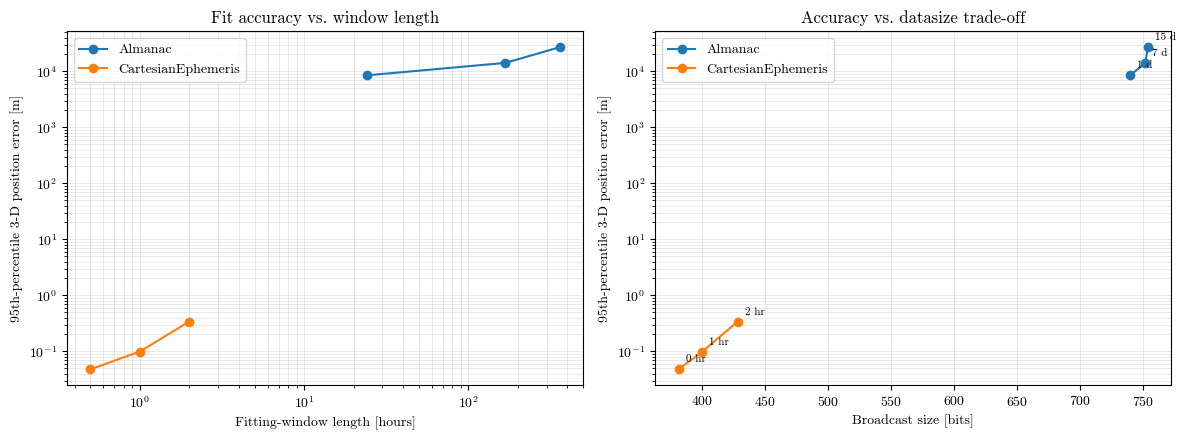

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

for label, sub in df.groupby("model"):
    sub = sub.sort_values("fit_window_min")
    win_hr = sub["fit_window_min"] / 60.0  # window length in hours
    axes[0].plot(win_hr, sub["pos_p95_m"], "o-", label=label)
    axes[1].plot(sub["total_bits"], sub["pos_p95_m"], "o-", label=label)
    for _, row in sub.iterrows():
        w_hr = row.fit_window_min / 60.0
        tag = f"{w_hr:.0f} hr" if w_hr < 24 else f"{w_hr / 24:.0f} d"
        axes[1].annotate(
            tag,
            (row.total_bits, row.pos_p95_m),
            textcoords="offset points",
            xytext=(5, 5),
            fontsize=8,
        )

axes[0].set_xlabel("Fitting-window length [hours]")
axes[0].set_xscale("log")
axes[0].set_ylabel("95th-percentile 3-D position error [m]")
axes[0].set_yscale("log")
axes[0].set_title("Fit accuracy vs. window length")
axes[0].legend()
axes[0].grid(True, which="both", lw=0.4, alpha=0.5)

axes[1].set_xlabel("Broadcast size [bits]")
axes[1].set_ylabel("95th-percentile 3-D position error [m]")
axes[1].set_yscale("log")
axes[1].set_title("Accuracy vs. datasize trade-off")
axes[1].legend()
axes[1].grid(True, which="both", lw=0.4, alpha=0.5)

plt.tight_layout()
plt.show()

## Ephemeris bit allocation per parameter

The trade-off above summarizes each fit by a single `total_bits`. Here we open up
that number for the `CartesianEphemeris` and show how the broadcast bits are
distributed across its parameters: the six Keplerian baseline elements (a, e, i,
RAAN, argument of perigee, reference mean anomaly) and the three per-axis
Chebyshev position-correction blocks (x, y, z), stacked by coefficient order. For
each parameter a bisection search finds the coarsest quantization (fewest
fractional bits) that still keeps the worst-case position error under the target
precision, and the integer part is sized from the parameter's range -- exactly
the budget behind the ephemeris point in the trade-off, so the bars sum to that
same total.

CartesianEphemeris 120-min window (MOON_PA), poly_order 6: 428 total bits (matches the ephemeris trade-off point)


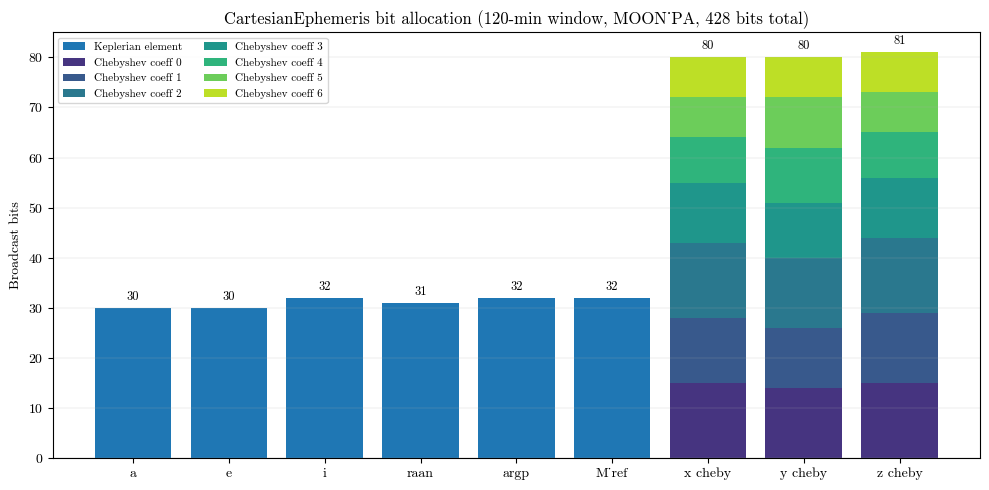

In [10]:
# Per-parameter bit allocation behind the ephemeris "total_bits" in the trade-off
# above. Mirrors SummarizeWindows / SearchParamBits / RangeBits in
# cpp/lupnt/simulations/ephemeris/ephemeris_simulation.cc: for each parameter a
# bisection finds the fewest fractional bits whose quantization keeps the
# worst-case (max-over-window) position error under datasize_precision_m, and the
# integer part is sized from the parameter's range. Same settings as the ephemeris
# sweep (poly_order 6, datasize_precision_m 0.05, num_windows 4, 120-min window,
# MOON_PA output), so the bars sum to that sweep's ephemeris total_bits.
bit_window_min = 120.0
bit_precision_m = 0.05
bit_num_windows = 4

opt_bits = pnt.EphemerisFitOptions()
opt_bits.poly_order = 6
opt_bits.use_keplerian_baseline = True
opt_bits.frame = pnt.MOON_PA
eph_bits = pnt.CartesianEphemeris(opt_bits)
bit_names = eph_bits.param_names()
n_bit_params = eph_bits.num_params()

# Fit in MOON_PA, matching the sweep: convert the 1-day ephemeris truth arc once.
rv_truth_eph_pa = pnt.convert_frame(
    t0 + t_eph_s, rv_truth_eph, pnt.MOON_CI, pnt.MOON_PA
)


def _search_param_bits(eph, t_s, params, idx, precision_m, max_bits=50):
    base = eph.eval(t_s, params)[:, :3]

    def perturbed_err(k):
        eps = 2.0 ** (-k)
        q = params.copy()
        q[idx] += eps
        plus = eph.eval(t_s, q)[:, :3]
        q[idx] -= 2.0 * eps
        minus = eph.eval(t_s, q)[:, :3]
        return max(
            np.max(np.linalg.norm(plus - base, axis=1)),
            np.max(np.linalg.norm(minus - base, axis=1)),
        )

    lo, hi = 0, max_bits
    if perturbed_err(lo) <= precision_m:
        return lo
    if perturbed_err(hi) > precision_m:
        return hi
    while hi - lo > 1:
        mid = (lo + hi) // 2
        if perturbed_err(mid) <= precision_m:
            hi = mid
        else:
            lo = mid
    return hi


def _range_bits(rng, bits_frac, signed, margin):
    bits_range = max(1, int(np.ceil(np.log2(rng)))) if rng > 0 else 1
    return bits_range + max(bits_frac, 0) + (1 if signed else 0) + (1 if margin else 0)


def _classify(name):
    # (range, signed, margin_bit); range=None means "use the parameter's max |value|"
    if (
        name[0] == "i"
        or name.startswith("raan")
        or name.startswith("argp")
        or name[0] == "M"
    ):
        return 2.0 * np.pi, True, False  # angular element
    if name[0] == "e":
        return 1.0, False, False  # eccentricity in [0, 1)
    if name[0] == "a":
        return None, False, True  # semi-major axis
    return None, True, True  # Chebyshev coefficient


# Sample the same windows the sweep uses across the 1-day ephemeris truth arc.
n_arc = len(t_eph_s)
win_pts = int(round(bit_window_min * pnt.SECS_MINUTE / eph_dt_s)) + 1
margin = win_pts // 2
span = max(1, n_arc - 1 - 2 * margin)
starts = []
for wnd in range(bit_num_windows):
    frac = wnd / (bit_num_windows - 1) if bit_num_windows > 1 else 0.5
    s = margin + int(round(frac * span)) - win_pts // 2
    starts.append(max(0, min(s, n_arc - win_pts)))

max_k = np.zeros(n_bit_params)
max_abs = np.zeros(n_bit_params)
for s in starts:
    t_win = t_eph_s[s : s + win_pts]
    rv_win = rv_truth_eph_pa[s : s + win_pts]
    p_fit = eph_bits.fit(t_win, rv_win)
    for j in range(
        2, n_bit_params
    ):  # params 0,1 (t_ref, t_fit) are not broadcast-quantized
        max_abs[j] = max(max_abs[j], abs(p_fit[j]))
        max_k[j] = max(
            max_k[j], _search_param_bits(eph_bits, t_win, p_fit, j, bit_precision_m)
        )

param_bits = np.zeros(n_bit_params, dtype=int)
for j in range(2, n_bit_params):
    rng, signed, margin_bit = _classify(bit_names[j])
    if rng is None:
        rng = max_abs[j]
    param_bits[j] = _range_bits(rng, int(max_k[j]), signed, margin_bit)

total_bits = int(param_bits.sum())
print(
    f"CartesianEphemeris {bit_window_min:.0f}-min window (MOON_PA), poly_order "
    f"{opt_bits.poly_order}: {total_bits} total bits (matches the ephemeris trade-off point)"
)

# Bar plot: Keplerian elements (single bars) + x/y/z Chebyshev blocks
# (stacked by coefficient order).
kep = ["a", "e", "i", "raan", "argp", "M_ref"]
kep_bits = [param_bits[bit_names.index(nm)] for nm in kep]
poly = opt_bits.poly_order
labels = kep + ["x cheby", "y cheby", "z cheby"]
xpos = np.arange(len(labels))

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(xpos[:6], kep_bits, color="C0", label="Keplerian element")

coeff_colors = plt.cm.viridis(np.linspace(0.15, 0.9, poly + 1))
for axi, axis_name in enumerate("xyz"):
    bottom = 0
    for k in range(poly + 1):
        b = param_bits[bit_names.index(f"{axis_name}_{k}")]
        ax.bar(
            6 + axi,
            b,
            bottom=bottom,
            color=coeff_colors[k],
            label=f"Chebyshev coeff {k}" if axi == 0 else None,
        )
        bottom += b

for idx_, lbl in enumerate(labels):
    tot = (
        kep_bits[idx_]
        if idx_ < 6
        else sum(param_bits[bit_names.index(f"{lbl[0]}_{k}")] for k in range(poly + 1))
    )
    ax.text(idx_, tot + 1, str(int(tot)), ha="center", va="bottom", fontsize=9)

ax.set_xticks(xpos)
ax.set_xticklabels(labels)
ax.set_ylabel("Broadcast bits")
ax.set_title(
    f"CartesianEphemeris bit allocation "
    f"({bit_window_min:.0f}-min window, MOON_PA, {total_bits} bits total)"
)
ax.grid(True, axis="y", lw=0.3, alpha=0.5)
ax.legend(ncol=2, fontsize=8, loc="upper left")
plt.tight_layout()
plt.show()

### Takeaways

- A precise ephemeris and a coarse almanac are different points on the same compression problem: fewer bits and longer validity usually mean larger prediction error.
- `CartesianEphemeris` removes most of the orbital motion analytically with a two-body baseline, so the Chebyshev polynomial only fits the smooth perturbation residual.
- `Almanac` is intentionally lower fidelity but remains useful for acquisition, pointing, and coarse geometry over many days.
- Expressing fit error in RTN coordinates reveals whether the model is dominated by radial, along-track, or cross-track compression error.
- The same LuPNT classes used here can be embedded in constellation simulations to study broadcast-message design.